# 2D теплообмен с произвольным k(x,y)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
from typing import Callable, Dict, Tuple, List

def make_grid(Nx: int, Ny: int, Lx: float = 1.0, Ly: float = 1.0):
    x = np.linspace(0.0, Lx, Nx + 1)
    y = np.linspace(0.0, Ly, Ny + 1)
    dx = Lx / Nx
    dy = Ly / Ny
    X, Y = np.meshgrid(x, y)
    return x, y, X, Y, dx, dy

def trapz2_uniform(u: np.ndarray, dx: float, dy: float) -> float:
    return dy * (dx * (0.25 * (u[0, 0] + u[0, -1] + u[-1, 0] + u[-1, -1]) +
                       0.5 * (u[0, 1:-1].sum() + u[-1, 1:-1].sum()) +
                       0.5 * (u[1:-1, 0].sum() + u[1:-1, -1].sum()) +
                       u[1:-1, 1:-1].sum()))

def k_heart(X: np.ndarray, Y: np.ndarray, k0: float = 1.0, delta: float = 1.0) -> np.ndarray:
    Xn = (X - 0.5) * 2.6
    Yn = (Y - 0.5) * 2.6
    F = (Xn**2 + Yn**2 - 1.0)**3 - Xn**2 * Yn**3
    mask = (F <= 0.0).astype(float)
    return k0 * (1.0 + delta * mask)

def k_smooth_heart(X: np.ndarray, Y: np.ndarray, k0: float = 1.0, delta: float = 1.0, eps: float = 0.05) -> np.ndarray:
    Xn = (X - 0.5) * 2.6
    Yn = (Y - 0.5) * 2.6
    F = (Xn**2 + Yn**2 - 1.0)**3 - Xn**2 * Yn**3
    smooth_mask = 0.5 * (1.0 - np.tanh(F / eps))
    return k0 * (1.0 + delta * smooth_mask)

def face_conductivities(k: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    kx = 0.5 * (k[:, 1:] + k[:, :-1])
    ky = 0.5 * (k[1:, :] + k[:-1, :])
    return kx, ky

def L_operator_2d(u: np.ndarray, kx: np.ndarray, ky: np.ndarray, dx: float, dy: float) -> np.ndarray:
    out = np.zeros_like(u)
    Uc = u[1:-1, 1:-1]
    Uxp = (u[1:-1, 2:] - Uc)
    Uxm = (Uc - u[1:-1, 0:-2])
    Lx = (kx[1:-1, 1:] * Uxp - kx[1:-1, 0:-1] * Uxm) / (dx * dx)
    Uyp = (u[2:, 1:-1] - Uc)
    Uym = (Uc - u[0:-2, 1:-1])
    Ly = (ky[1:, 1:-1] * Uyp - ky[0:-1, 1:-1] * Uym) / (dy * dy)
    out[1:-1, 1:-1] = Lx + Ly
    return out

def solve_ftcs_2d(Nx:int, Ny:int, T:float, kfun:Callable, k_params:dict, cfl:float=0.9,
                  snapshots:List[float]=None, Lx:float=1.0, Ly:float=1.0) -> Dict[str, np.ndarray]:
    x, y, X, Y, dx, dy = make_grid(Nx, Ny, Lx, Ly)
    k = kfun(X, Y, **k_params)
    kx, ky = face_conductivities(k)
    kmax = float(np.max(k))
    dt = cfl * min(dx,dy)**2 / (4.0 * kmax)
    Nt = int(np.ceil(T / dt)); dt = T/Nt
    sigma = 0.02
    u = np.exp(-(((X - 0.5)**2 + (Y - 0.5)**2) / (2.0 * sigma**2)))
    u[0,:]=0; u[-1,:]=0; u[:,0]=0; u[:,-1]=0
    times = np.linspace(0.0, T, Nt+1)
    E = np.empty(Nt+1); E[0]=trapz2_uniform(u,dx,dy)
    snaps = {}; need=set(snapshots or [])
    if 0.0 in need: snaps[0.0]=u.copy()
    for n in range(1, Nt+1):
        Lu = L_operator_2d(u, kx, ky, dx, dy)
        u[1:-1,1:-1] += dt * Lu[1:-1,1:-1]
        E[n]=trapz2_uniform(u,dx,dy)
        t=n*dt
        for ts in list(need):
            if ts not in snaps and abs(t-ts)<=0.5*dt:
                snaps[ts]=u.copy()
    return {"x":x,"y":y,"X":X,"Y":Y,"u":u,"times":times,"energies":E,"dt":dt,"dx":dx,"dy":dy,"k":k,"snapshots":snaps}

def cg(matvec: Callable[[np.ndarray], np.ndarray], b: np.ndarray, x0: np.ndarray = None, tol: float = 1e-8, maxiter: int = 2000):
    x = np.zeros_like(b) if x0 is None else x0.copy()
    r = b - matvec(x)
    p = r.copy()
    rsold = np.dot(r, r)
    for it in range(maxiter):
        Ap = matvec(p)
        alpha = rsold / (np.dot(p, Ap) + 1e-30)
        x += alpha * p
        r -= alpha * Ap
        rsnew = np.dot(r, r)
        if np.sqrt(rsnew) < tol:
            return x, it + 1, True
        p = r + (rsnew / rsold) * p
        rsold = rsnew
    return x, maxiter, False

def solve_implicit_be_2d(Nx:int, Ny:int, T:float, kfun:Callable, k_params:dict, dt:float,
                         snapshots:List[float]=None, Lx:float=1.0, Ly:float=1.0, tol:float=1e-8, maxiter:int=1500) -> Dict[str, np.ndarray]:
    x, y, X, Y, dx, dy = make_grid(Nx, Ny, Lx, Ly)
    k = kfun(X, Y, **k_params)
    kx, ky = face_conductivities(k)
    sigma = 0.02
    u = np.exp(-(((X - 0.5)**2 + (Y - 0.5)**2) / (2.0 * sigma**2)))
    u[0,:]=0; u[-1,:]=0; u[:,0]=0; u[:,-1]=0
    Nt = int(np.ceil(T/dt)); dt = T/Nt
    times = np.linspace(0.0, T, Nt+1)
    E = np.empty(Nt+1); E[0]=trapz2_uniform(u,dx,dy)
    snaps = {}; need=set(snapshots or [])
    if 0.0 in need: snaps[0.0]=u.copy()
    def to_full(v): U=np.zeros((Ny+1,Nx+1)); U[1:-1,1:-1]=v.reshape((Ny-1,Nx-1)); return U
    def to_int(U): return U[1:-1,1:-1].ravel()
    def A_mv(v):
        U = to_full(v)
        LU = L_operator_2d(U, kx, ky, dx, dy)
        AU = U.copy(); AU[1:-1,1:-1] -= dt * LU[1:-1,1:-1]
        return to_int(AU)
    for n in range(1,Nt+1):
        b = to_int(u)
        x0 = b
        v, iters, ok = cg(A_mv, b, x0=x0, tol=tol, maxiter=maxiter)
        u = to_full(v)
        E[n]=trapz2_uniform(u,dx,dy)
        t=n*dt
        for ts in list(need):
            if ts not in snaps and abs(t-ts)<=0.5*dt:
                snaps[ts]=u.copy()
    return {"x":x,"y":y,"X":X,"Y":Y,"u":u,"times":times,"energies":E,"dt":dt,"dx":dx,"dy":dy,"k":k,"snapshots":snaps}

def run_experiment(Nx=80, Ny=80, T=0.05, k0=1.0, delta=1.25, smooth=True, snapshot_times=[0.005,0.02,0.05]):
    kfun = (lambda X,Y,k0,delta: k_smooth_heart(X,Y,k0=k0,delta=delta,eps=0.03)) if smooth else \
           (lambda X,Y,k0,delta: k_heart(X,Y,k0=k0,delta=delta))
    x, y, X, Y, dx, dy = make_grid(Nx, Ny)
    K = kfun(X, Y, k0=k0, delta=delta)
    kmax = float(np.max(K))
    dt_exp = 0.9 * min(dx,dy)**2 / (4.0 * kmax)
    results = {}
    perf_rows = []
    t0=time.perf_counter()
    sol_exp = solve_ftcs_2d(Nx, Ny, T, kfun, {"k0":k0,"delta":delta}, cfl=0.9, snapshots=snapshot_times)
    t1=time.perf_counter()
    perf_rows.append({"scheme":"FTCS (explicit)", "dt": sol_exp["dt"], "Nt": len(sol_exp["times"])-1, "runtime [s]": t1-t0})
    results[("FTCS", round(sol_exp["dt"],12))] = sol_exp
    for mult in [1, 10, 40]:
        dt_try = mult * dt_exp
        t0=time.perf_counter()
        sol_imp = solve_implicit_be_2d(Nx, Ny, T, kfun, {"k0":k0,"delta":delta}, dt=dt_try, snapshots=snapshot_times, tol=1e-6, maxiter=800)
        t1=time.perf_counter()
        perf_rows.append({"scheme":"Backward Euler (implicit)", "dt": sol_imp["dt"], "Nt": len(sol_imp["times"])-1, "runtime [s]": t1-t0})
        results[("BE", mult)] = sol_imp
    df = pd.DataFrame(perf_rows)
    return df, results, (X, Y, K)


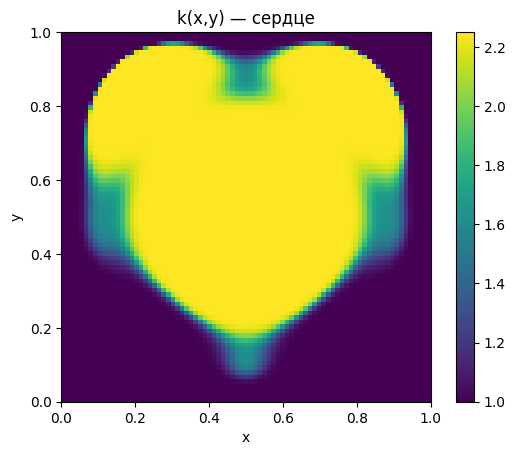

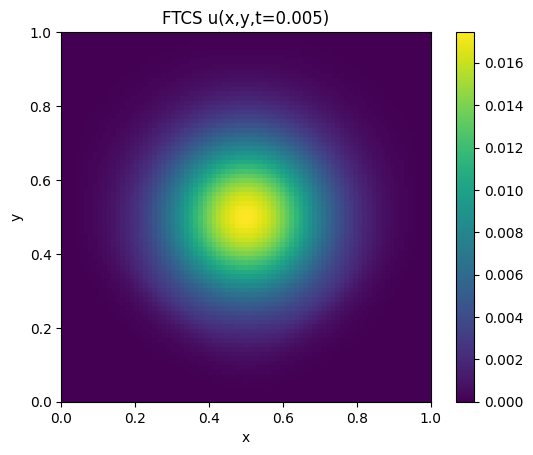

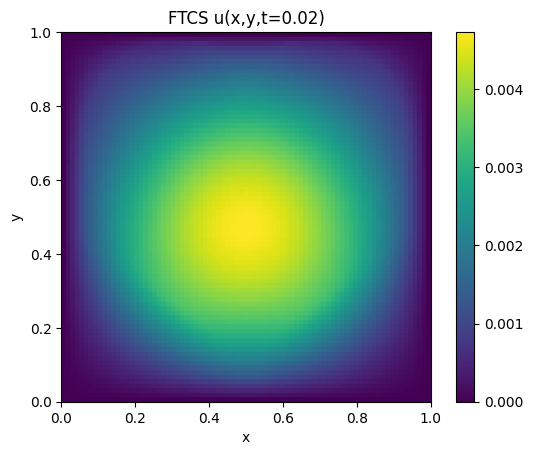

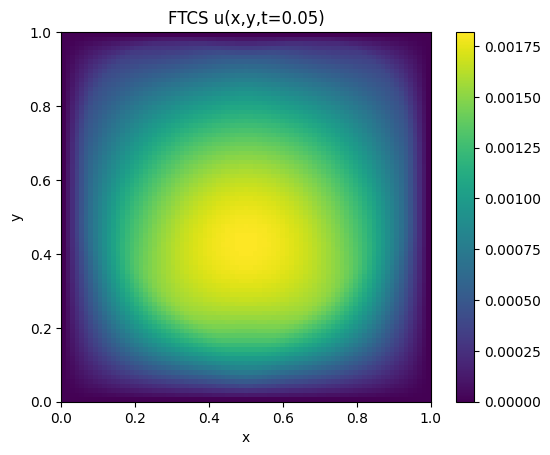

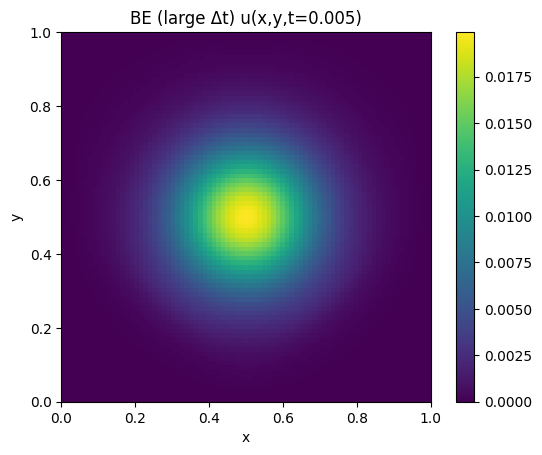

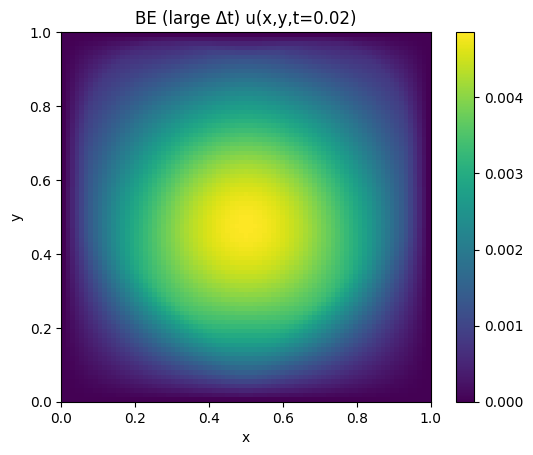

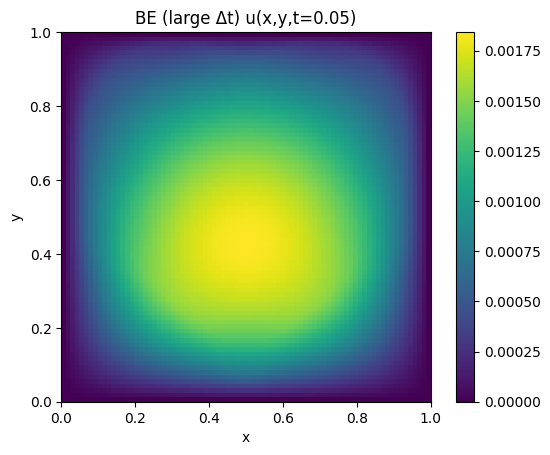

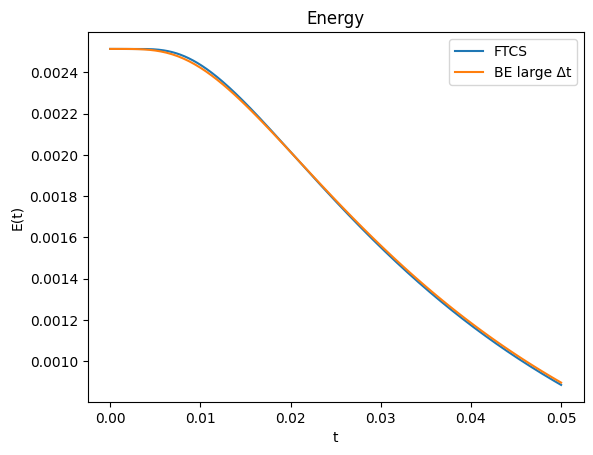

In [2]:
# Параметры
Nx, Ny = 80, 80
T_end = 0.05
snapshot_times = [0.005, 0.02, 0.05]

df_perf, results, (Xg, Yg, Kmap) = run_experiment(Nx=Nx, Ny=Ny, T=T_end, k0=1.0, delta=1.25, smooth=True, snapshot_times=snapshot_times)

# Производительность
df_perf

# Визуализации
plt.figure(); plt.imshow(Kmap, origin='lower', extent=[0,1,0,1], aspect='equal'); plt.title('k(x,y) — сердце'); plt.xlabel('x'); plt.ylabel('y'); plt.colorbar(); plt.show()

dt_exp_key = [k for (name,k) in results.keys() if name=='FTCS'][0]
sol_exp = results[('FTCS', dt_exp_key)]
sol_imp = results[('BE', 40)]

for t in snapshot_times:
    plt.figure(); plt.imshow(sol_exp['snapshots'][t], origin='lower', extent=[0,1,0,1], aspect='equal'); plt.title(f'FTCS u(x,y,t={t})'); plt.xlabel('x'); plt.ylabel('y'); plt.colorbar(); plt.show()

for t in snapshot_times:
    plt.figure(); plt.imshow(sol_imp['snapshots'][t], origin='lower', extent=[0,1,0,1], aspect='equal'); plt.title(f'BE (large Δt) u(x,y,t={t})'); plt.xlabel('x'); plt.ylabel('y'); plt.colorbar(); plt.show()

plt.figure(); plt.plot(sol_exp['times'], sol_exp['energies'], label='FTCS'); plt.plot(sol_imp['times'], sol_imp['energies'], label='BE large Δt'); plt.xlabel('t'); plt.ylabel('E(t)'); plt.title('Energy'); plt.legend(); plt.show()
